# Land-Cover Classification in Richmond upon Thames, London (2020, 2022, 2024)

## Notebook 02 – Unsupervised Classification: KMeans Clustering

This notebook applies **unsupervised KMeans clustering** to Sentinel-2 land-cover samples from Richmond upon Thames, London.

Unlike supervised classification, KMeans does not use predefined land-cover labels. Instead, it groups pixels based on similarities in spectral features, including Sentinel-2 bands and NDVI.

The analysis compares clustering results across three years:

- 2020
- 2022
- 2024

The resulting clusters are then compared with the reference land-cover classes prepared in **Notebook 01** to evaluate how well the unsupervised classification matches known land-cover types.

## 1. Setup

This section imports the Python libraries required for unsupervised clustering, feature scaling, visualisation and evaluation.

In [28]:
# ==========================
# Setup
# ==========================

import time
start_time = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)

%matplotlib inline

print("Setup complete.")

Setup complete.


## 2. Load the preprocessed dataset

The cleaned multi-year dataset prepared in Notebook #1 is loaded for unsupervised clustering.

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
df_2020 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2020_samples.csv")
df_2022 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2022_samples.csv")
df_2024 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2024_samples.csv")

df_2020["year"] = 2020
df_2022["year"] = 2022
df_2024["year"] = 2024

df = pd.concat([df_2020, df_2022, df_2024], ignore_index=True)

df = df.drop(columns=["system:index", ".geo"], errors="ignore")

class_names = {
    1: "Water",
    2: "Vegetation",
    3: "Urban",
    4: "Bare soil / bright surface"
}

df["class_name"] = df["label"].map(class_names)

df.head()

,B2,B3,B4,B8,NDVI,label,year,class_name
0,255.0,311.0,218.0,251.0,0.070362,1,2020,Water
1,392.0,569.0,532.0,1490.0,0.473788,1,2020,Water
2,245.0,340.0,237.0,356.0,0.200675,1,2020,Water
3,262.0,320.0,199.0,183.0,-0.041885,1,2020,Water
4,288.0,412.0,295.0,370.0,0.112782,1,2020,Water


## 3. Select spectral features

KMeans clustering uses Sentinel-2 spectral bands and NDVI as input features.

In [31]:
# Select features for clustering
X = df[['B2', 'B3', 'B4', 'B8', 'NDVI']]

X.head()

,B2,B3,B4,B8,NDVI
0,255.0,311.0,218.0,251.0,0.070362
1,392.0,569.0,532.0,1490.0,0.473788
2,245.0,340.0,237.0,356.0,0.200675
3,262.0,320.0,199.0,183.0,-0.041885
4,288.0,412.0,295.0,370.0,0.112782


In [32]:
print("Feature matrix shape:", X.shape)

Feature matrix shape: (9384, 5)


## 4. Standardise features

The spectral bands and NDVI were standardised before clustering to ensure that all variables contribute equally to the KMeans algorithm.

In [33]:
# Standardise features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (9384, 5)


In [34]:
# Convert to dataframe for inspection
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['B2', 'B3', 'B4', 'B8', 'NDVI']
)

X_scaled_df.head()

,B2,B3,B4,B8,NDVI
0,-0.827345,-1.110493,-1.031942,-1.256927,-1.050344
1,-0.336819,-0.273523,-0.207262,-0.279755,0.327775
2,-0.863150,-1.016415,-0.982041,-1.174116,-0.605193
3,-0.802281,-1.081296,-1.081843,-1.310557,-1.433785
4,-0.709189,-0.782842,-0.829711,-1.163074,-0.905437


## 5. Determine the number of clusters

The elbow method was used to identify a suitable number of clusters for KMeans classification.

In [35]:
# Elbow method
inertia = []

k_values = range(1, 10)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

print("Elbow calculation complete.")

Elbow calculation complete.


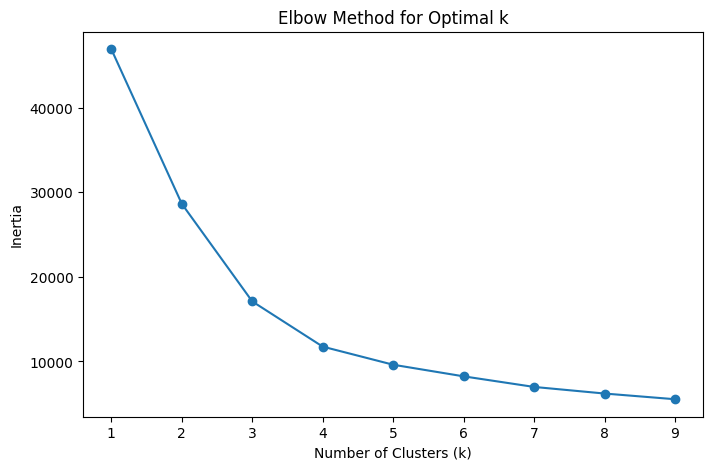

In [36]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()

## 6. Run KMeans clustering

KMeans clustering was performed using four clusters based on the elbow method results.

In [37]:
# Run KMeans clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("KMeans clustering complete.")

KMeans clustering complete.


In [38]:
# Add cluster labels to dataframe
df['cluster'] = clusters

df.head()

,B2,B3,B4,B8,NDVI,label,year,class_name,cluster
0,255.0,311.0,218.0,251.0,0.070362,1,2020,Water,1
1,392.0,569.0,532.0,1490.0,0.473788,1,2020,Water,3
2,245.0,340.0,237.0,356.0,0.200675,1,2020,Water,1
3,262.0,320.0,199.0,183.0,-0.041885,1,2020,Water,1
4,288.0,412.0,295.0,370.0,0.112782,1,2020,Water,1


In [39]:
# Count pixels in each cluster
cluster_counts = df['cluster'].value_counts().sort_index()

print(cluster_counts)

cluster
0    3263
1    2910
2     208
3    3003
Name: count, dtype: int64


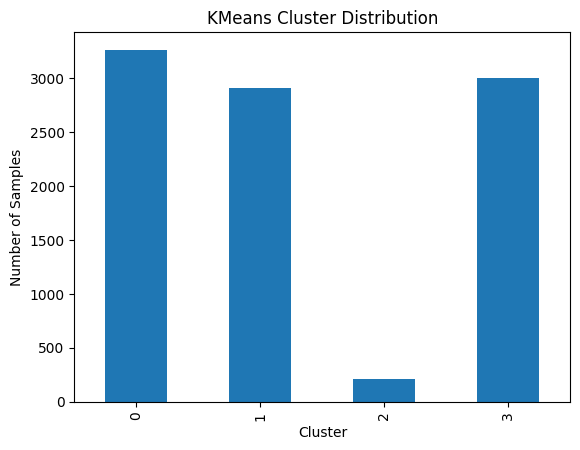

In [40]:
cluster_counts.plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("KMeans Cluster Distribution")

plt.show()

## 7. Interpret cluster characteristics

Mean spectral values were calculated for each cluster to interpret the land cover types represented by the KMeans results.

In [41]:
import pandas as pd

# Mean feature values for each cluster
cluster_means = df.groupby('cluster')[['B2', 'B3', 'B4', 'B8', 'NDVI']].mean()

# Create centroid summary table
df_centroids = pd.DataFrame(cluster_means)

# Add interpretation
df_centroids['Likely Class'] = [
    'Urban',
    'Water',
    'Bare soil / bright surface',
    'Vegetation'
]

# Round values
df_centroids = df_centroids.round(3)

# Display styled table
df_centroids.style.set_caption(
    "K-Means Cluster Centroids and Interpretations"
)

,B2,B3,B4,B8,NDVI,Likely Class
cluster,,,,,,
0,695.556000,854.761000,915.320000,1889.406000,0.333000,Urban
1,283.367000,378.208000,292.012000,377.668000,0.094000,Water
2,1572.608000,1832.707000,1971.312000,2445.865000,0.109000,Bare soil / bright surface
3,379.617000,619.324000,494.957000,3176.129000,0.720000,Vegetation


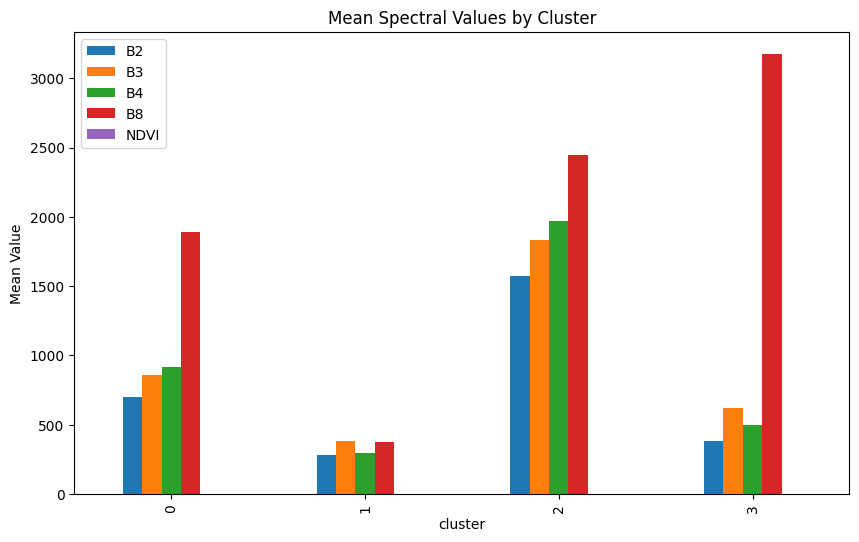

In [42]:
cluster_means.plot(kind='bar', figsize=(10,6))

plt.title("Mean Spectral Values by Cluster")
plt.ylabel("Mean Value")

plt.show()

## 8. Assign land cover meaning to clusters

Clusters were interpreted based on their spectral characteristics and assigned to approximate land cover types.

In [43]:
# Assign land cover names to clusters
cluster_names = {
    0: 'Urban',
    1: 'Water',
    2: 'Bare soil / bright surface',
    3: 'Vegetation'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

df.head()

,B2,B3,B4,B8,NDVI,label,year,class_name,cluster,cluster_name
0,255.0,311.0,218.0,251.0,0.070362,1,2020,Water,1,Water
1,392.0,569.0,532.0,1490.0,0.473788,1,2020,Water,3,Vegetation
2,245.0,340.0,237.0,356.0,0.200675,1,2020,Water,1,Water
3,262.0,320.0,199.0,183.0,-0.041885,1,2020,Water,1,Water
4,288.0,412.0,295.0,370.0,0.112782,1,2020,Water,1,Water


## 9. Compare KMeans clusters across years

The KMeans cluster results were compared across 2020, 2022 and 2024 to examine temporal differences in the unsupervised classification.

In [44]:
# Count cluster names by year
year_cluster_counts = df.groupby(['year', 'cluster_name']).size().unstack(fill_value=0)

year_cluster_counts

cluster_name,Bare soil / bright surface,Urban,Vegetation,Water
year,,,,
2020,66,1112,970,980
2022,73,1148,943,964
2024,69,1003,1090,966


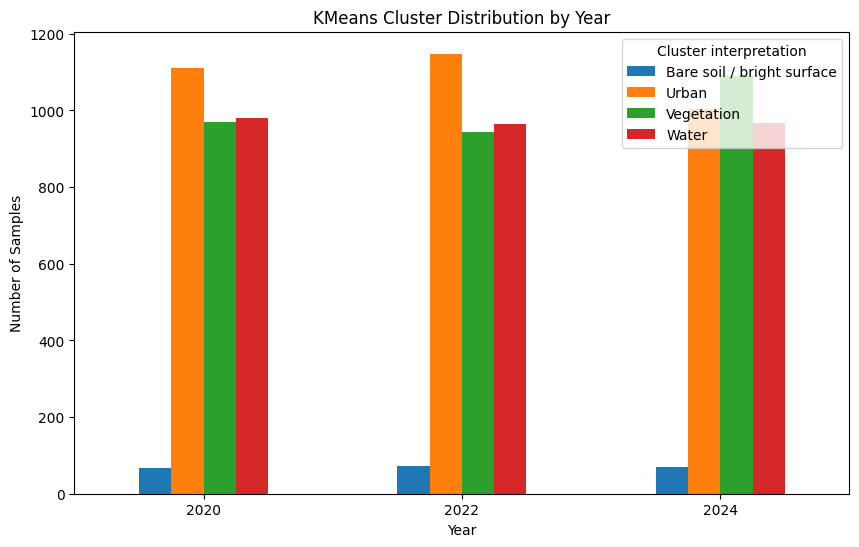

In [45]:
year_cluster_counts.plot(kind='bar', figsize=(10,6))

plt.title("KMeans Cluster Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Cluster interpretation")
plt.show()

## 10. Compare KMeans clusters with reference labels

The KMeans clustering results were compared with the reference ESA WorldCover labels to assess how well unsupervised clustering approximates land cover classes.

In [46]:
# Compare cluster interpretation with actual labels
comparison = pd.crosstab(
    df['class_name'],
    df['cluster_name']
)

comparison

cluster_name,Bare soil / bright surface,Urban,Vegetation,Water
class_name,,,,
Bare soil / bright surface,24,79,0,281
Urban,163,2526,278,33
Vegetation,12,499,2470,19
Water,9,159,255,2577


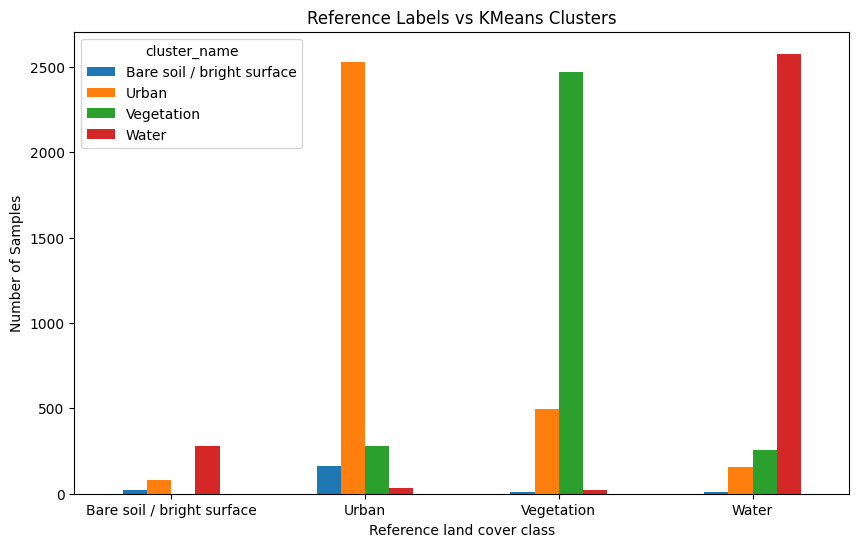

In [47]:
comparison.plot(kind='bar', figsize=(10,6))

plt.title("Reference Labels vs KMeans Clusters")
plt.xlabel("Reference land cover class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

## 11. Generate KMeans Cluster Maps
Visualisation of the spatial distribution of KMeans cluster classes for each year.

In [48]:
import json
import geopandas as gpd
from shapely.geometry import shape
from matplotlib.patches import Patch

In [49]:
import os
print(os.listdir("/content/drive/MyDrive/AI final project"))

['richmond_2020_samples.csv', 'richmond_2022_samples.csv', 'richmond_2024_samples.csv', 'richmond_features_2020.tif', 'richmond_features_2022.tif', 'richmond_features_2024.tif', '02_unsupervised_kmeans_richmond.ipynb', '03_supervised_randomforest_richmond.ipynb', '01_preprocessing_richmond_landcover.ipynb']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


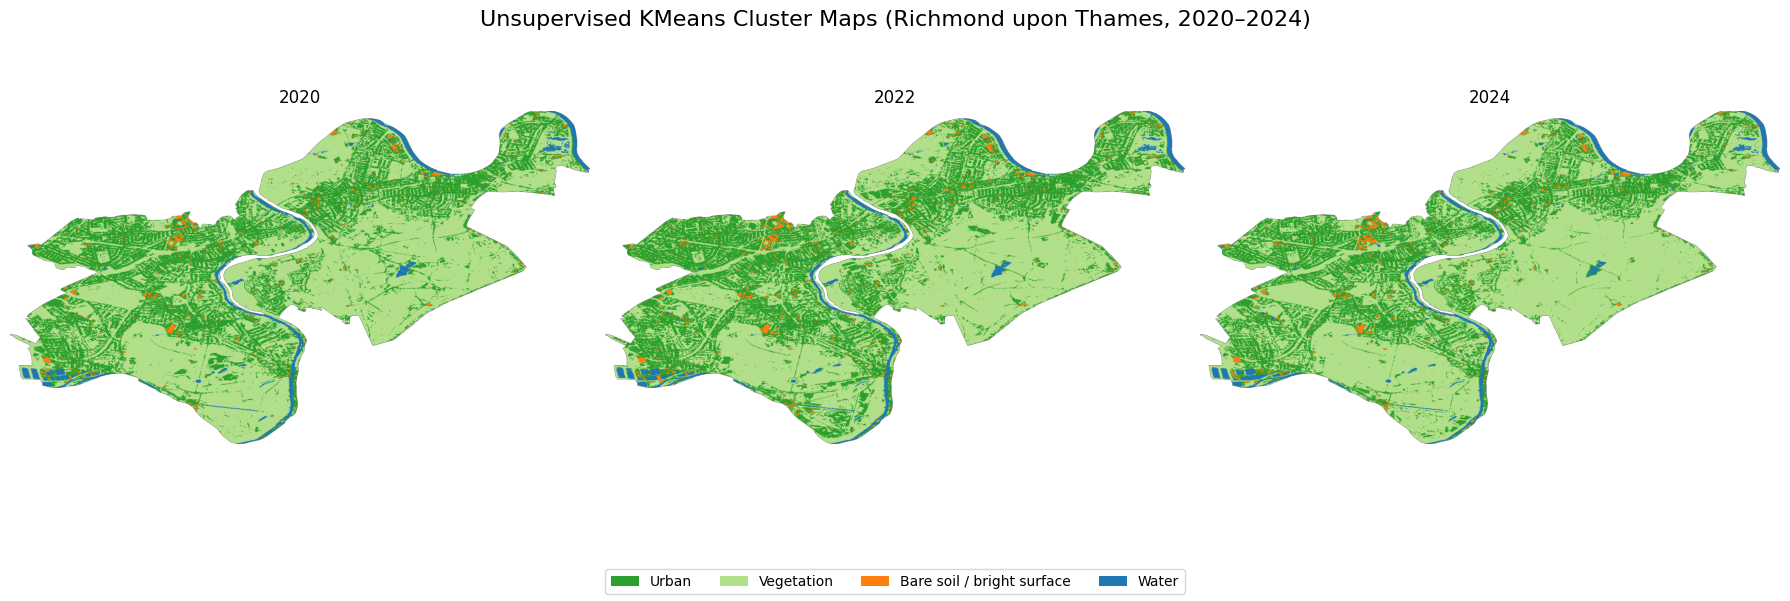

In [50]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

feature_files = {
    2020: "/content/drive/MyDrive/AI final project/richmond_features_2020.tif",
    2022: "/content/drive/MyDrive/AI final project/richmond_features_2022.tif",
    2024: "/content/drive/MyDrive/AI final project/richmond_features_2024.tif"
}

# Same cluster interpretation from Python KMeans
# 0 = Urban
# 1 = Water
# 2 = Bare soil / bright surface
# 3 = Vegetation
cmap = ListedColormap([
    "#2ca02c",  # Urban
    "#1f77b4",  # Water
    "#ff7f0e",  # Bare soil / bright surface
    "#b2df8a"   # Vegetation
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (year, path) in zip(axes, feature_files.items()):
    with rasterio.open(path) as src:
        img = src.read()  # shape: bands, rows, cols

        # Convert to rows, cols, bands
        img = np.moveaxis(img, 0, -1)

        rows, cols, bands = img.shape

        # Flatten pixels
        flat = img.reshape(-1, bands)

        # Mask invalid pixels
        valid_mask = np.all(np.isfinite(flat), axis=1)
        valid_mask &= np.any(flat != 0, axis=1)

        # Scale using the SAME scaler from Notebook #2
        # Convert flat[valid_mask] to float64 to match the scaler's expected dtype
        flat_scaled = scaler.transform(flat[valid_mask].astype(np.float64))

        # Predict using the SAME KMeans model from Notebook #2
        pred = np.full(flat.shape[0], np.nan)
        pred[valid_mask] = kmeans.predict(flat_scaled)

        classified = pred.reshape(rows, cols)

        ax.imshow(classified, cmap=cmap, norm=norm)
        ax.set_title(str(year))
        ax.axis("off")

legend_elements = [
    Patch(facecolor="#2ca02c", label="Urban"),
    Patch(facecolor="#b2df8a", label="Vegetation"),
    Patch(facecolor="#ff7f0e", label="Bare soil / bright surface"),
    Patch(facecolor="#1f77b4", label="Water")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=4)

fig.suptitle(
    "Unsupervised KMeans Cluster Maps (Richmond upon Thames, 2020–2024)",
    fontsize=16
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

## 12. Environmental Cost

In [51]:
# End timer and estimate environmental cost

end_time = time.time()
duration_sec = end_time - start_time
duration_hr = duration_sec / 3600

# Assumptions
CPU_POWER_W = 20                 # assumed CPU power in watts
CARBON_INTENSITY = 0.233         # kg CO2e per kWh, UK grid average
ELECTRICITY_COST = 0.30          # GBP per kWh

# Calculations
energy_kwh = (CPU_POWER_W / 1000) * duration_hr
co2_kg = energy_kwh * CARBON_INTENSITY
co2_g = co2_kg * 1000
cost_gbp = energy_kwh * ELECTRICITY_COST

print("Environmental cost estimate")
print("---------------------------")
print(f"Runtime: {duration_sec:.2f} seconds")
print(f"Runtime: {duration_hr:.4f} hours")
print(f"Energy used: {energy_kwh:.6f} kWh")
print(f"CO2 emitted: {co2_g:.3f} g CO2e")
print(f"Estimated electricity cost: £{cost_gbp:.4f}")

Environmental cost estimate
---------------------------
Runtime: 13.19 seconds
Runtime: 0.0037 hours
Energy used: 0.000073 kWh
CO2 emitted: 0.017 g CO2e
Estimated electricity cost: £0.0000


## 13. Conclusion

The unsupervised KMeans clustering successfully separated major land cover types in Richmond upon Thames.

Key findings:

- Water was clearly identified due to low spectral reflectance.
- Vegetation was well separated due to high near-infrared reflectance and NDVI.
- Urban areas formed a distinct cluster with intermediate spectral values.
- Bare soil / bright surfaces were less accurately separated because of their smaller sample size and spectral similarity to urban surfaces.

Overall, KMeans provided a useful unsupervised approximation of land cover classes and produced results broadly consistent with the reference ESA WorldCover labels.